In [1]:
# Plot decadal average differences of OSDMA8_BC

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from scipy import stats
from utils.utils import autosize_figure
from utils.utils import land_filter

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, dates, start, end, time_mean=False, land_mask=False):
    """
    land_mask=True allows for the land filter function to remove the ocean
    """
    ens = []

    for ens_num in range(1, 11):
        da = xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{dates}.nc").sel(year=slice(start, end))
        if time_mean is True:
            da = da.mean("year")
        ens.append(da)

    new_da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        new_da = land_filter(new_da)

    return new_da

In [4]:
# === Stats functions ===
def process_da_for_stats(da, start_year, end_year):
    da_r = da.sel(time=slice(start_year, end_year)).sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(time=slice(start_year, end_year)).sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r


def stat_sig(da1, da2):
    # For latitude, longitude plots
    stat, pval = stats.ttest_ind(da1, da2)
    pval_da = xr.DataArray(data=pval,
                           dims=["lat", "lon"],
                           coords=dict(lon=(["lon"], da1.lon.values),
                                       lat=(["lat"], da1.lat.values)))
    return pval_da

In [5]:
def alt_process_da_for_stats(da):
    da_r = da.sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r

In [6]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

# === Main loop ===
arise_30s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2068", "2035", "2039", time_mean=True, land_mask=True)
ssp245_30s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2068", "2035", "2039", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [7]:
arise_40s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2068", "2040", "2049", time_mean=True, land_mask=True)
ssp245_40s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2068", "2040", "2049", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [8]:
arise_50s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2068", "2050", "2059", time_mean=True, land_mask=True)
ssp245_50s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2068", "2050", "2059", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [9]:
arise_60s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2068", "2060", "2068", time_mean=True, land_mask=True)
ssp245_60s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2068", "2060", "2068", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [10]:
diff_30s = (arise_30s - ssp245_30s).mean("ensemble")
diff_40s = (arise_40s - ssp245_40s).mean("ensemble")
diff_50s = (arise_50s - ssp245_50s).mean("ensemble")
diff_60s = (arise_60s - ssp245_60s).mean("ensemble")

In [11]:
arise_30s_proc = alt_process_da_for_stats(arise_30s)
ssp245_30s_proc = alt_process_da_for_stats(ssp245_30s)

In [12]:
stat_sig(arise_30s_proc, ssp245_30s_proc)


KeyboardInterrupt



In [ ]:
pval_30s = stat_sig(arise_30s, ssp245_30s)
pval_40s = stat_sig(arise_40s, ssp245_40s)
pval_50s = stat_sig(arise_50s, ssp245_50s)
pval_60s = stat_sig(arise_60s, ssp245_60s)

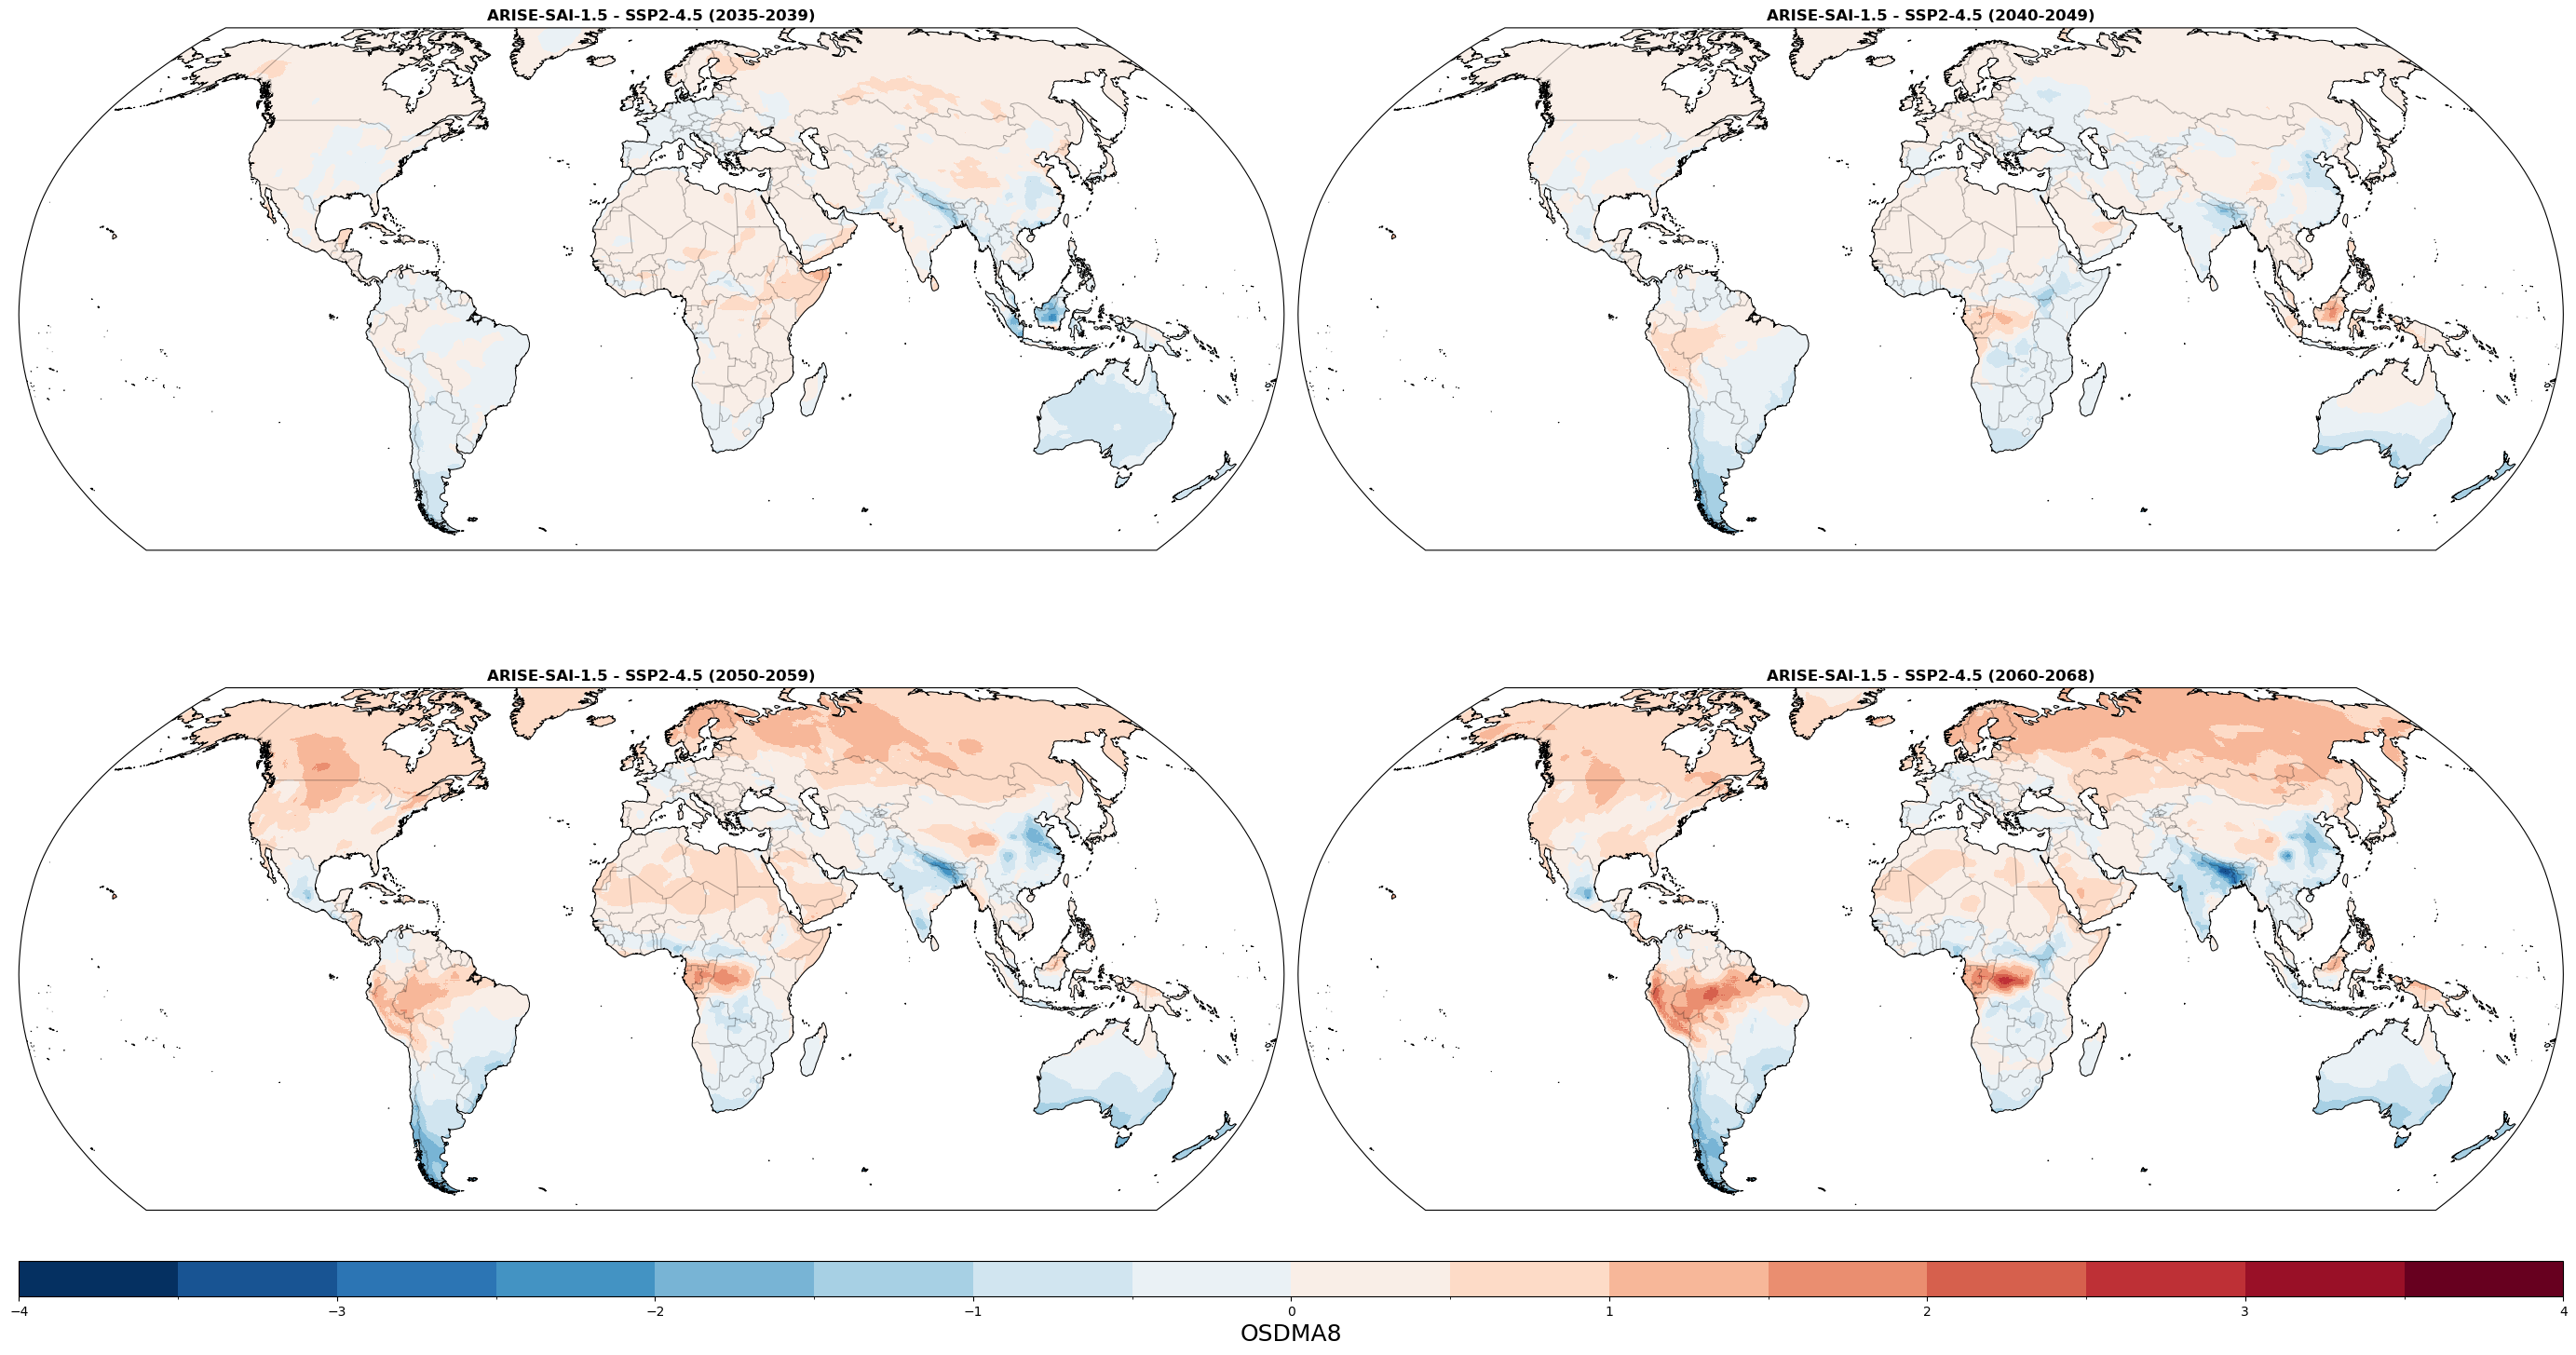

In [13]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(diff_30s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_30s.where(pval_30s > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['...'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2035-2039)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = land_filter(diff_40s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_40s.where(pval_40s > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['...'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2040-2049)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = land_filter(diff_50s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_50s.where(pval_50s > 0.05).plot.contourf(transform=crs, colors='none',
#                                              levels=[0, 1], hatches=['...'],
#                                              add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2050-2059)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = land_filter(diff_60s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_60s.where(pval_60s > 0.05).plot.contourf(transform=crs, colors='none',
#                                              levels=[0, 1], hatches=['...'],
#                                              add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2060-2068)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('OSDMA8', fontsize=18)

plt.tight_layout()